# Project: Yelp Rating Regression Predictor

We have six files, listed below with a brief description:
* `yelp_business.json`: establishment data regarding location and attributes for all businesses in the dataset
* `yelp_review.json`: Yelp review metadata by business
* `yelp_user.json`: user profile metadata by business
* `yelp_checkin.json`: online checkin metadata by business
* `yelp_tip.json`: tip metadata by business
* `yelp_photo.json`: photo metadata by business

## Section :- Data Preview and Cleaning

### 1st Step :- PREVIEW OF DATA

In [2]:
import pandas as pd

#Exploring business.json

business_df = pd.read_json('yelp_business.json', lines=True)
business_df.to_csv('yelp_business.csv', index=False)

business_df.head()

,address,alcohol?,attributes,business_id,categories,city,good_for_kids,has_bike_parking,has_wifi,hours,...,longitude,name,neighborhood,postal_code,price_range,review_count,stars,state,take_reservations,takes_credit_cards
0,1314 44 Avenue NE,0,"{'BikeParking': 'False', 'BusinessAcceptsCredi...",Apn5Q_b6Nz61Tq4XzPdf9A,"Tours, Breweries, Pizza, Restaurants, Food, Ho...",Calgary,1,0,0,"{'Monday': '8:30-17:0', 'Tuesday': '11:0-21:0'...",...,-114.031675,Minhas Micro Brewery,,T2E 6L6,2,24,4.0,AB,1,1
1,,0,"{'Alcohol': 'none', 'BikeParking': 'False', 'B...",AjEbIBw6ZFfln7ePHha9PA,"Chicken Wings, Burgers, Caterers, Street Vendo...",Henderson,1,0,0,"{'Friday': '17:0-23:0', 'Saturday': '17:0-23:0...",...,-114.939821,CK'S BBQ & Catering,,89002,2,3,4.5,NV,0,1
2,1335 rue Beaubien E,1,"{'Alcohol': 'beer_and_wine', 'Ambience': '{'ro...",O8S5hYJ1SMc8fA4QBtVujA,"Breakfast & Brunch, Restaurants, French, Sandw...",Montréal,1,1,1,"{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",...,-73.599300,La Bastringue,Rosemont-La Petite-Patrie,H2G 1K7,2,5,4.0,QC,1,0
3,211 W Monroe St,0,None,bFzdJJ3wp3PZssNEsyU23g,"Insurance, Financial Services",Phoenix,0,0,0,None,...,-112.076979,Geico Insurance,,85003,0,8,1.5,AZ,0,0
4,2005 Alyth Place SE,0,{'BusinessAcceptsCreditCards': 'True'},8USyCYqpScwiNEb58Bt6CA,"Home & Garden, Nurseries & Gardening, Shopping...",Calgary,0,0,0,"{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ...",...,-114.027366,Action Engine,,T2H 0N5,0,4,2.0,AB,0,1


In [3]:
#Exploring checkin.json

checkin_df = pd.read_json('yelp_checkin.json', lines=True)
checkin_df.to_csv('yelp_checkin.csv', index=False)

checkin_df.head()
#checkin_df.info()

,business_id,time,weekday_checkins,weekend_checkins
0,7KPBkxAOEtb3QeIL9PEErg,"{'Fri-0': 2, 'Sat-0': 1, 'Sun-0': 1, 'Wed-0': ...",76,75
1,kREVIrSBbtqBhIYkTccQUg,"{'Mon-13': 1, 'Thu-13': 1, 'Sat-16': 1, 'Wed-1...",4,3
2,tJRDll5yqpZwehenzE2cSg,"{'Thu-0': 1, 'Mon-1': 1, 'Mon-12': 1, 'Sat-16'...",3,3
3,tZccfdl6JNw-j5BKnCTIQQ,"{'Sun-14': 1, 'Fri-18': 1, 'Mon-20': 1}",1,2
4,r1p7RAMzCV_6NPF0dNoR3g,"{'Sat-3': 1, 'Sun-18': 1, 'Sat-21': 1, 'Sat-23...",1,4


In [4]:
#Exploring data.json

data_df = pd.read_json('yelp_data.json', lines=True)
data_df.to_csv('yelp_data.csv', index=False)

data_df.head()
#data_df.info()

,address,attributes,business_id,categories,city,hours,is_open,latitude,longitude,name,...,stars,state,alcohol?,has_bike_parking,takes_credit_cards,good_for_kids,price_range,take_reservations,has_wifi,pic_count
0,1314 44 Avenue NE,"{'BikeParking': 'False', 'BusinessAcceptsCredi...",Apn5Q_b6Nz61Tq4XzPdf9A,"Tours, Breweries, Pizza, Restaurants, Food, Ho...",Calgary,"{'Monday': '8:30-17:0', 'Tuesday': '11:0-21:0'...",1,51.091813,-114.031675,Minhas Micro Brewery,...,4.0,AB,0,0,1,1,2,1,0,NaN
1,,"{'Alcohol': 'none', 'BikeParking': 'False', 'B...",AjEbIBw6ZFfln7ePHha9PA,"Chicken Wings, Burgers, Caterers, Street Vendo...",Henderson,"{'Friday': '17:0-23:0', 'Saturday': '17:0-23:0...",0,35.960734,-114.939821,CK'S BBQ & Catering,...,4.5,NV,0,0,1,1,2,0,0,1.0
2,1335 rue Beaubien E,"{'Alcohol': 'beer_and_wine', 'Ambience': '{'ro...",O8S5hYJ1SMc8fA4QBtVujA,"Breakfast & Brunch, Restaurants, French, Sandw...",Montréal,"{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",0,45.540503,-73.599300,La Bastringue,...,4.0,QC,1,1,0,1,2,1,1,NaN
3,211 W Monroe St,None,bFzdJJ3wp3PZssNEsyU23g,"Insurance, Financial Services",Phoenix,None,1,33.449999,-112.076979,Geico Insurance,...,1.5,AZ,0,0,0,0,0,0,0,NaN
4,2005 Alyth Place SE,{'BusinessAcceptsCreditCards': 'True'},8USyCYqpScwiNEb58Bt6CA,"Home & Garden, Nurseries & Gardening, Shopping...",Calgary,"{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ...",1,51.035591,-114.027366,Action Engine,...,2.0,AB,0,0,1,0,0,0,0,NaN


In [5]:
#Exploring photo.json

photo_df = pd.read_json('yelp_photo.json', lines=True)
photo_df.to_csv('yelp_photo.csv', index=False)

photo_df.head()
#photo_df.info()

,business_id,average_caption_length,number_pics
0,--1UhMGODdWsrMastO9DZw,0.000000,1
1,--6MefnULPED_I942VcFNA,67.500000,2
2,--9e1ONYQuAa-CB_Rrw7Tw,30.426471,136
3,--DaPTJW3-tB1vP-PfdTEg,0.000000,1
4,--FBCX-N37CMYDfs790Bnw,5.500000,4


In [6]:
#Exploring review.json

review_df = pd.read_json('yelp_review.json', lines=True)
review_df.to_csv('yelp_review.csv', index=False)

review_df.head()
#review_df.info()

,business_id,average_review_age,average_review_length,average_review_sentiment,number_funny_votes,number_cool_votes,number_useful_votes
0,--1UhMGODdWsrMastO9DZw,524.458333,466.208333,0.808638,1,16,15
1,--6MefnULPED_I942VcFNA,1199.589744,785.205128,0.669126,27,32,53
2,--7zmmkVg-IMGaXbuVd0SQ,717.851852,536.592593,0.820837,29,52,81
3,--8LPVSo5i0Oo61X01sV9A,751.750000,478.250000,0.170925,0,0,9
4,--9QQLMTbFzLJ_oT-ON3Xw,978.727273,436.181818,0.562264,3,4,7


In [7]:
#Exploring tip.json

tip_df = pd.read_json('yelp_tip.json', lines=True)
tip_df.to_csv('yelp_tip.csv', index=False)

tip_df.head()
#tip_df.info()

,business_id,average_tip_length,number_tips
0,--1UhMGODdWsrMastO9DZw,79.000000,1
1,--6MefnULPED_I942VcFNA,49.857143,14
2,--7zmmkVg-IMGaXbuVd0SQ,52.500000,10
3,--9QQLMTbFzLJ_oT-ON3Xw,136.500000,2
4,--9e1ONYQuAa-CB_Rrw7Tw,68.064935,154


In [8]:
#Exploring user.json

user_df = pd.read_json('yelp_user.json', lines=True)
user_df.to_csv('yelp_user.csv', index=False)

user_df.head()
#user_df.info()

,business_id,average_number_friends,average_days_on_yelp,average_number_fans,average_review_count,average_number_years_elite
0,--1UhMGODdWsrMastO9DZw,18.791667,1789.750000,1.833333,57.541667,0.833333
1,--6MefnULPED_I942VcFNA,214.564103,2039.948718,49.256410,332.743590,1.769231
2,--7zmmkVg-IMGaXbuVd0SQ,126.185185,1992.796296,19.222222,208.962963,1.814815
3,--8LPVSo5i0Oo61X01sV9A,25.250000,2095.750000,0.500000,7.500000,0.000000
4,--9QQLMTbFzLJ_oT-ON3Xw,52.454545,1804.636364,1.000000,34.636364,0.090909


### Step 2 :- Joining And Cleaning of Data

In [9]:
# Joining The DataFrames
df = business_df.merge(checkin_df, on='business_id', how='left') \
                .merge(review_df,  on='business_id', how='left') \
                .merge(tip_df,     on='business_id', how='left') \
                .merge(user_df,    on='business_id', how='left')

df.to_csv('yelp_merged.csv', index=False)
df.head()

,address,alcohol?,attributes,business_id,categories,city,good_for_kids,has_bike_parking,has_wifi,hours,...,number_funny_votes,number_cool_votes,number_useful_votes,average_tip_length,number_tips,average_number_friends,average_days_on_yelp,average_number_fans,average_review_count,average_number_years_elite
0,1314 44 Avenue NE,0,"{'BikeParking': 'False', 'BusinessAcceptsCredi...",Apn5Q_b6Nz61Tq4XzPdf9A,"Tours, Breweries, Pizza, Restaurants, Food, Ho...",Calgary,1,0,0,"{'Monday': '8:30-17:0', 'Tuesday': '11:0-21:0'...",...,6,5,13,38.0,6.0,42.833333,1809.375000,5.375000,114.875000,1.125000
1,,0,"{'Alcohol': 'none', 'BikeParking': 'False', 'B...",AjEbIBw6ZFfln7ePHha9PA,"Chicken Wings, Burgers, Caterers, Street Vendo...",Henderson,1,0,0,"{'Friday': '17:0-23:0', 'Saturday': '17:0-23:0...",...,0,1,1,66.0,1.0,64.333333,970.333333,2.666667,19.666667,0.666667
2,1335 rue Beaubien E,1,"{'Alcohol': 'beer_and_wine', 'Ambience': '{'ro...",O8S5hYJ1SMc8fA4QBtVujA,"Breakfast & Brunch, Restaurants, French, Sandw...",Montréal,1,1,1,"{'Monday': '10:0-22:0', 'Tuesday': '10:0-22:0'...",...,0,2,1,32.0,1.0,4.200000,1499.600000,1.000000,24.600000,0.600000
3,211 W Monroe St,0,None,bFzdJJ3wp3PZssNEsyU23g,"Insurance, Financial Services",Phoenix,0,0,0,None,...,1,0,3,NaN,NaN,12.500000,1626.500000,2.375000,68.000000,0.250000
4,2005 Alyth Place SE,0,{'BusinessAcceptsCreditCards': 'True'},8USyCYqpScwiNEb58Bt6CA,"Home & Garden, Nurseries & Gardening, Shopping...",Calgary,0,0,0,"{'Monday': '8:0-17:0', 'Tuesday': '8:0-17:0', ...",...,0,0,4,NaN,NaN,137.750000,2570.000000,26.750000,528.250000,4.250000


In [10]:
#Info of the merged dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188593 entries, 0 to 188592
Data columns (total 38 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   address                     188593 non-null  object 
 1   alcohol?                    188593 non-null  int64  
 2   attributes                  162807 non-null  object 
 3   business_id                 188593 non-null  object 
 4   categories                  188052 non-null  object 
 5   city                        188593 non-null  object 
 6   good_for_kids               188593 non-null  int64  
 7   has_bike_parking            188593 non-null  int64  
 8   has_wifi                    188593 non-null  int64  
 9   hours                       143791 non-null  object 
 10  is_open                     188593 non-null  int64  
 11  latitude                    188587 non-null  float64
 12  longitude                   188587 non-null  float64
 13  name          

In [11]:
#Cleaning the data

df = df.dropna()
df = df.drop(columns=[col for col in ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'categories', 'hours', 'attributes', 'neighborhood', 'time'] if col in df.columns])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 85274 entries, 0 to 188592
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   alcohol?                    85274 non-null  int64  
 1   good_for_kids               85274 non-null  int64  
 2   has_bike_parking            85274 non-null  int64  
 3   has_wifi                    85274 non-null  int64  
 4   is_open                     85274 non-null  int64  
 5   price_range                 85274 non-null  int64  
 6   review_count                85274 non-null  int64  
 7   stars                       85274 non-null  float64
 8   take_reservations           85274 non-null  int64  
 9   takes_credit_cards          85274 non-null  int64  
 10  weekday_checkins            85274 non-null  float64
 11  weekend_checkins            85274 non-null  float64
 12  average_review_age          85274 non-null  float64
 13  average_review_length       85274 n

## Section 2 :- Preparation for Training of Model

### Step 3 :- Checking Correlation

In [12]:
#Correlation matrix

df.corr()

,alcohol?,good_for_kids,has_bike_parking,has_wifi,is_open,price_range,review_count,stars,take_reservations,takes_credit_cards,...,number_funny_votes,number_cool_votes,number_useful_votes,average_tip_length,number_tips,average_number_friends,average_days_on_yelp,average_number_fans,average_review_count,average_number_years_elite
alcohol?,1.000000,0.261148,0.154332,0.334304,-0.124064,0.332295,0.240564,-0.066673,0.600415,0.103000,...,0.103122,0.168051,0.145870,-0.060250,0.183931,-0.033279,0.109508,-0.022185,-0.010340,0.061450
good_for_kids,0.261148,1.000000,0.176591,0.227839,-0.072438,0.068232,0.126570,-0.062764,0.278533,-0.017819,...,0.035940,0.076681,0.046697,-0.067940,0.121317,-0.068795,-0.037842,-0.048583,-0.034561,-0.007957
has_bike_parking,0.154332,0.176591,1.000000,0.159521,0.087670,0.309089,0.089583,0.061217,0.096370,0.115250,...,0.023371,0.058221,0.037217,-0.056853,0.089729,-0.003889,-0.058667,-0.009926,0.002766,0.040742
has_wifi,0.334304,0.227839,0.159521,1.000000,-0.029644,0.181322,0.155433,-0.059605,0.296791,0.049636,...,0.059806,0.114830,0.086763,-0.051546,0.134933,-0.014580,-0.022149,0.002576,0.027760,0.058218
is_open,-0.124064,-0.072438,0.087670,-0.029644,1.000000,-0.104687,0.054933,0.035389,-0.123818,-0.029089,...,0.009202,0.028107,0.028299,0.025134,0.019917,-0.074913,-0.380864,-0.086684,-0.077560,-0.126552
price_range,0.332295,0.068232,0.309089,0.181322,-0.104687,1.000000,0.117939,-0.051048,0.312323,0.187279,...,0.057977,0.095459,0.072951,-0.049453,0.080521,0.049351,0.132494,0.076651,0.100103,0.168315
review_count,0.240564,0.126570,0.089583,0.155433,0.054933,0.117939,1.000000,0.043822,0.163204,0.074974,...,0.537695,0.859927,0.740931,-0.030294,0.842215,0.022173,0.083084,-0.012190,-0.018296,-0.010097
stars,-0.066673,-0.062764,0.061217,-0.059605,0.035389,-0.051048,0.043822,1.000000,-0.039853,-0.034056,...,0.005635,0.063126,0.012897,-0.033422,0.020240,-0.013666,-0.027308,-0.029630,-0.078179,-0.073358
take_reservations,0.600415,0.278533,0.096370,0.296791,-0.123818,0.312323,0.163204,-0.039853,1.000000,0.036137,...,0.055013,0.106214,0.093629,-0.035259,0.105716,-0.073017,0.021468,-0.031883,-0.021114,0.033924
takes_credit_cards,0.103000,-0.017819,0.115250,0.049636,-0.029089,0.187279,0.074974,-0.034056,0.036137,1.000000,...,0.026808,0.039389,0.045125,-0.010051,0.053288,-0.000575,0.097833,-0.056950,-0.056218,-0.096585


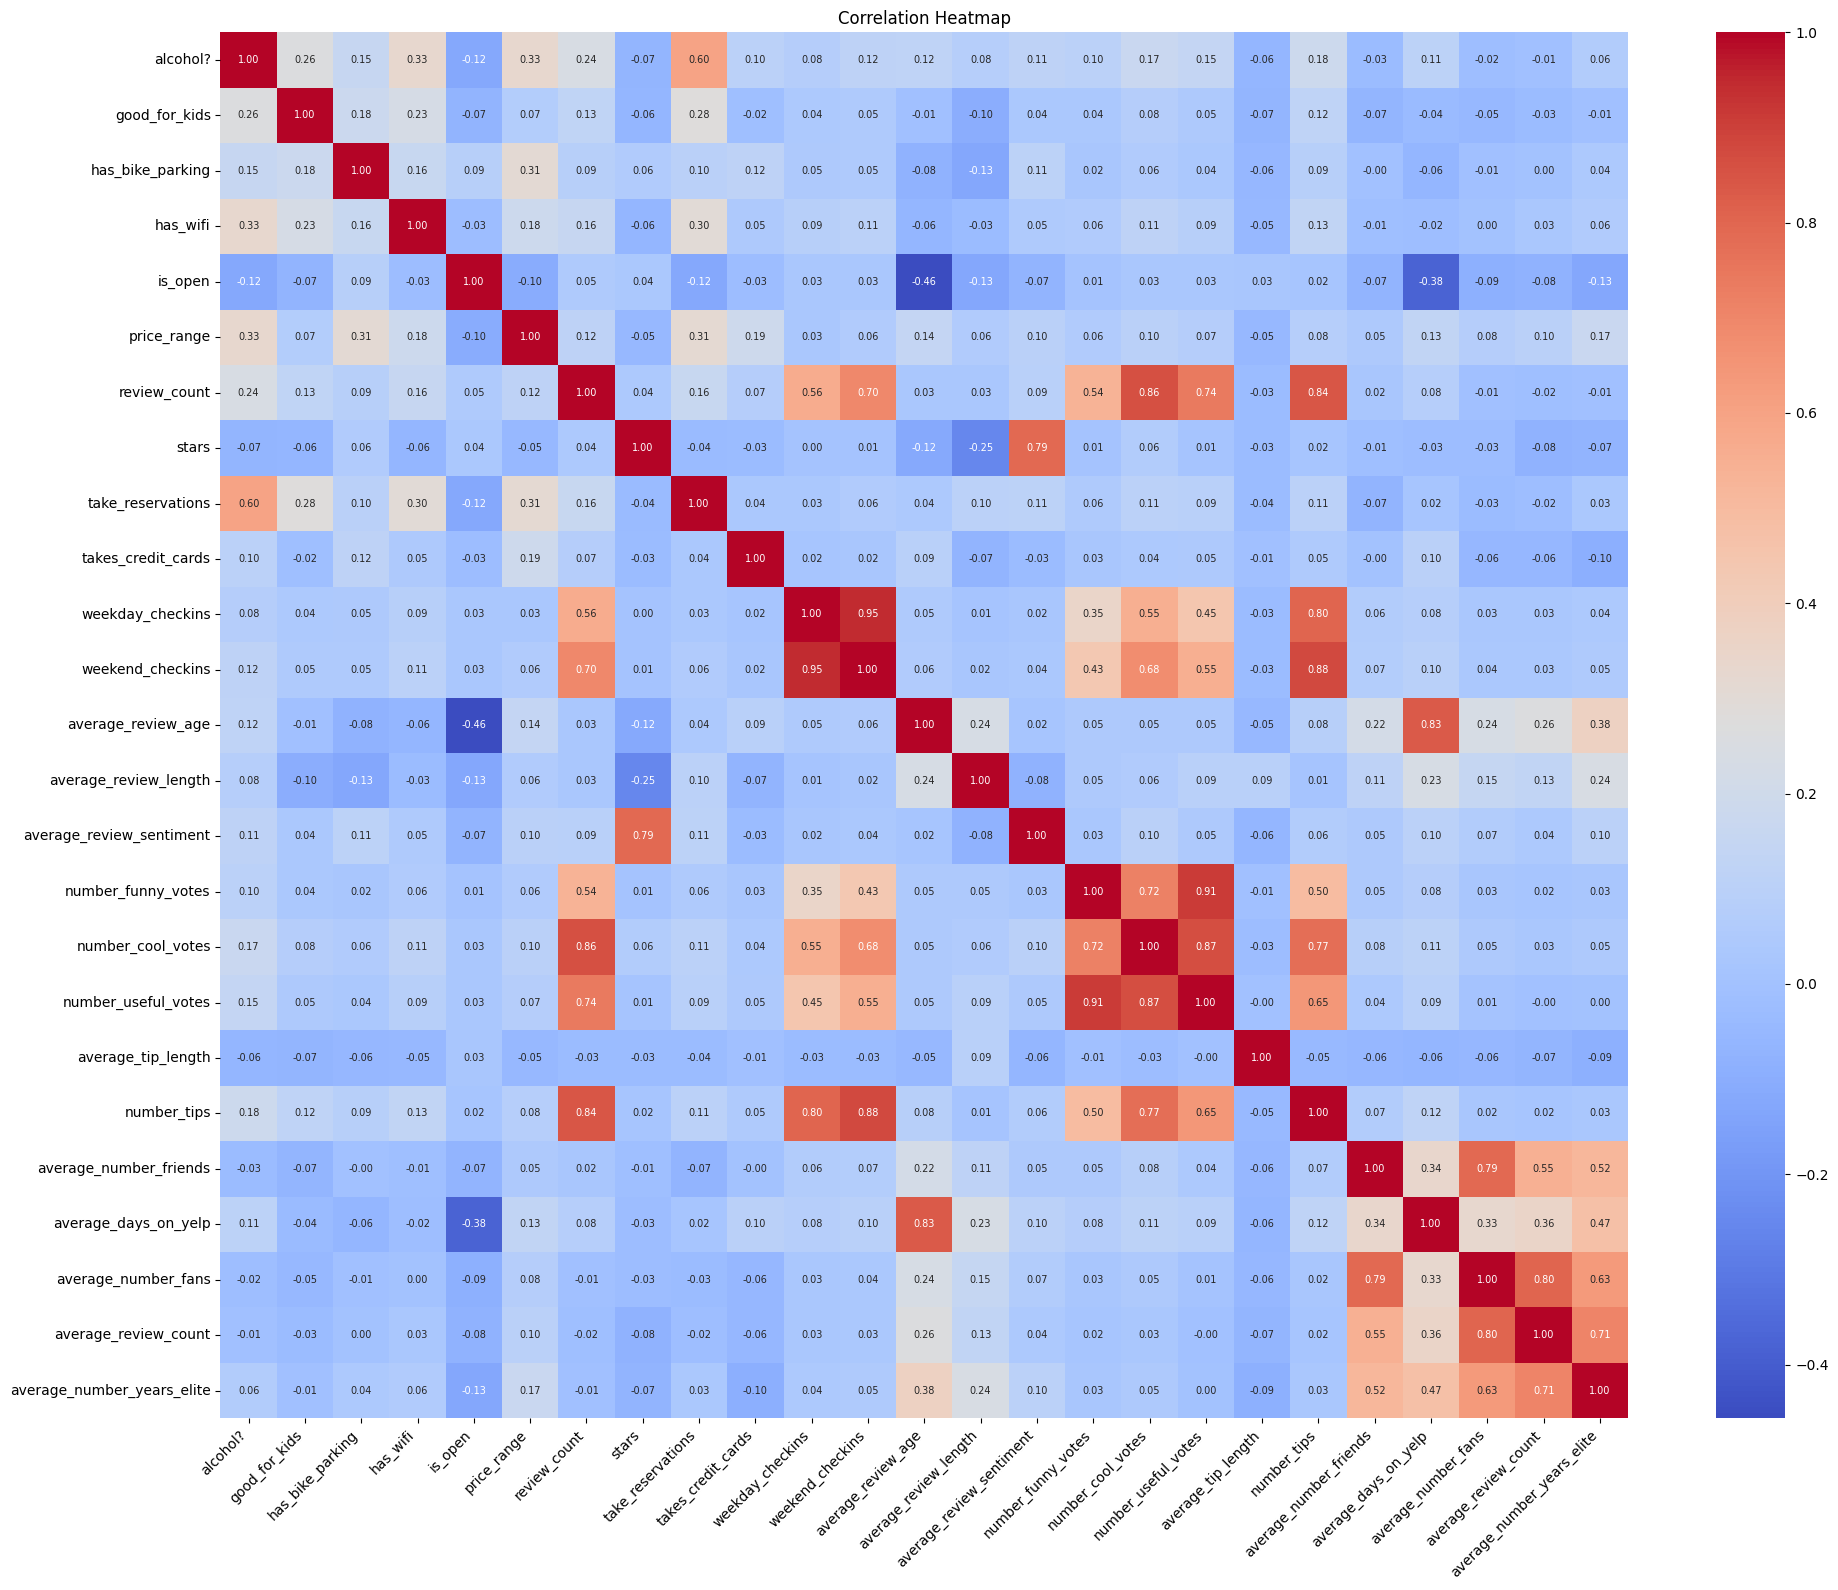

In [13]:
#correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', 
            annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 4 :- Plotting Data

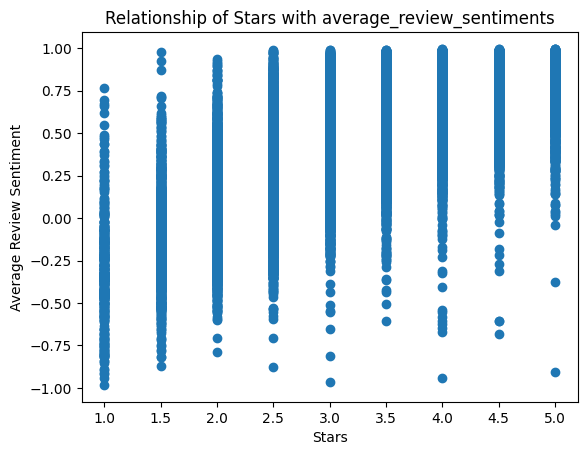

In [14]:
#Checking relationship of Stars with average_review_sentiments

plt.scatter(df['stars'], df['average_review_sentiment'])
plt.xlabel("Stars")
plt.ylabel("Average Review Sentiment")
plt.title("Relationship of Stars with average_review_sentiments")
plt.show()

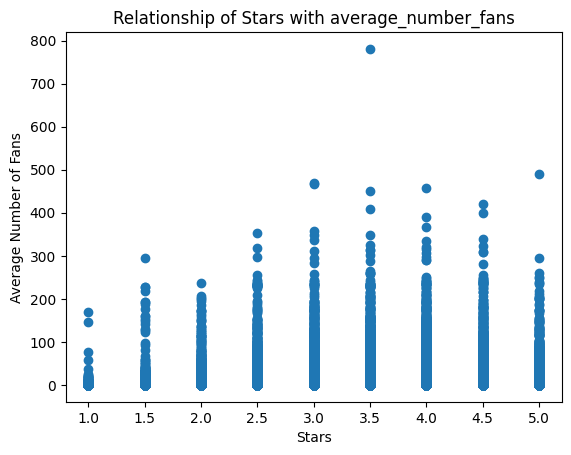

In [15]:
#Checking relationship of Stars with average_number_fans

plt.scatter(df['stars'], df['average_number_fans'])
plt.xlabel("Stars")
plt.ylabel("Average Number of Fans")
plt.title("Relationship of Stars with average_number_fans")
plt.show()

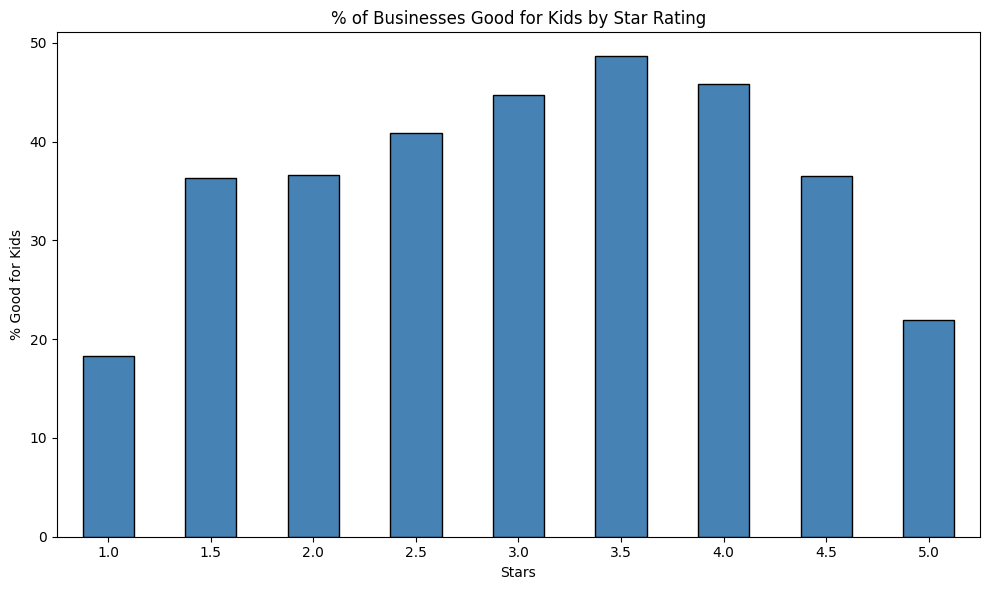

In [16]:
# Relationship of Stars with good_for_kids

kids_by_stars = df.groupby('stars')['good_for_kids'].mean() * 100  # % that are kid-friendly

plt.figure(figsize=(10, 6))
kids_by_stars.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel("Stars")
plt.ylabel("% Good for Kids")
plt.title("% of Businesses Good for Kids by Star Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Section 3 :- Training Model

### Step 5 :- Splitting Data into Train and Test Sets

In [17]:
df.columns

Index(['alcohol?', 'good_for_kids', 'has_bike_parking', 'has_wifi', 'is_open',
       'price_range', 'review_count', 'stars', 'take_reservations',
       'takes_credit_cards', 'weekday_checkins', 'weekend_checkins',
       'average_review_age', 'average_review_length',
       'average_review_sentiment', 'number_funny_votes', 'number_cool_votes',
       'number_useful_votes', 'average_tip_length', 'number_tips',
       'average_number_friends', 'average_days_on_yelp', 'average_number_fans',
       'average_review_count', 'average_number_years_elite'],
      dtype='object')

In [18]:
#defining x and y 
x = df[['alcohol?', 'good_for_kids', 'has_bike_parking', 'has_wifi', 'is_open',
       'price_range', 'review_count', 'take_reservations',
       'takes_credit_cards', 'weekday_checkins', 'weekend_checkins',
       'average_review_age', 'average_review_length',
       'average_review_sentiment', 'number_funny_votes', 'number_cool_votes',
       'number_useful_votes', 'average_tip_length', 'number_tips',
       'average_number_friends', 'average_days_on_yelp', 'average_number_fans',
       'average_review_count', 'average_number_years_elite']]

y = df[['stars']]

In [19]:
#Splitting x and y
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=42)

### Step 6 :- Creating and Training the Model

In [20]:
from sklearn.linear_model import LinearRegression

#Creating the Model(regr)

regr = LinearRegression()
regr.fit(x_train, y_train)

y_predict = regr.predict(x_test)

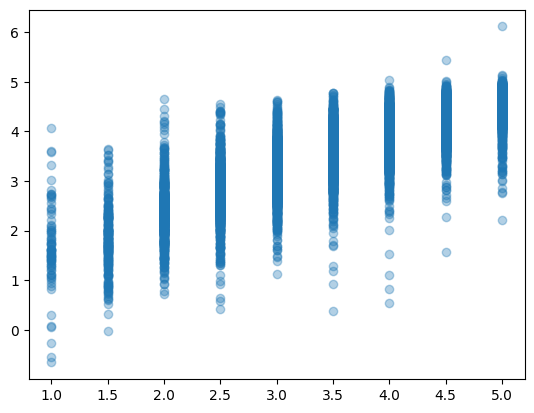

In [21]:
#Checking the model

plt.scatter(y_test, y_predict, alpha= 0.34)

### Step 7 :- Evaluation of Model 

In [22]:
regr.score(x_test,y_test)

0.7140992232401955

This shows that the model is able to get 66.7% of the logic from the given x data

## Section 4 :- Tuning the model

### Step 8 :-  Checking Coefficients 


In [23]:
regr.coef_

array([[-1.51400734e-01, -1.21619678e-01,  2.82840512e-03,
        -1.03643277e-01,  5.52736463e-02, -5.25821718e-02,
        -8.08458120e-05, -1.10529745e-02, -1.77266578e-02,
         3.57027718e-05, -6.20302877e-05, -1.31323731e-04,
        -6.44190797e-04,  2.48867868e+00, -4.12748032e-05,
         6.13225290e-04, -1.00377271e-04,  7.99950528e-05,
        -2.03657916e-04, -1.23540820e-06,  1.27369995e-04,
         1.29860589e-03, -2.99023461e-04, -6.92519817e-02]])

In [24]:
# Arranging the coefficients in order
coef_list = sorted(
    list(zip(x_train.columns, regr.coef_.flatten())), 
    reverse=False
)

for feature, coef in coef_list:
    print(f"{feature}: {coef:.4f}")

alcohol?: -0.1514
average_days_on_yelp: 0.0001
average_number_fans: 0.0013
average_number_friends: -0.0000
average_number_years_elite: -0.0693
average_review_age: -0.0001
average_review_count: -0.0003
average_review_length: -0.0006
average_review_sentiment: 2.4887
average_tip_length: 0.0001
good_for_kids: -0.1216
has_bike_parking: 0.0028
has_wifi: -0.1036
is_open: 0.0553
number_cool_votes: 0.0006
number_funny_votes: -0.0000
number_tips: -0.0002
number_useful_votes: -0.0001
price_range: -0.0526
review_count: -0.0001
take_reservations: -0.0111
takes_credit_cards: -0.0177
weekday_checkins: 0.0000
weekend_checkins: -0.0001


We can see that many features are useless, hence we will rebuild the model

### Step 9 :- Rebuilding the model 
We will rebuild the model by only keeping the useful features in the model

In [25]:
x = x.drop(columns=['weekday_checkins', 'weekend_checkins', 'review_count',
                    'number_useful_votes', 'number_funny_votes', 'average_tip_length',
                    'average_review_age', 'average_number_friends', 'average_days_on_yelp'])
x.head()
x.columns

Index(['alcohol?', 'good_for_kids', 'has_bike_parking', 'has_wifi', 'is_open',
       'price_range', 'take_reservations', 'takes_credit_cards',
       'average_review_length', 'average_review_sentiment',
       'number_cool_votes', 'number_tips', 'average_number_fans',
       'average_review_count', 'average_number_years_elite'],
      dtype='object')

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=42)
regr.fit(x_train, y_train)
y_predict = regr.predict(x_test)

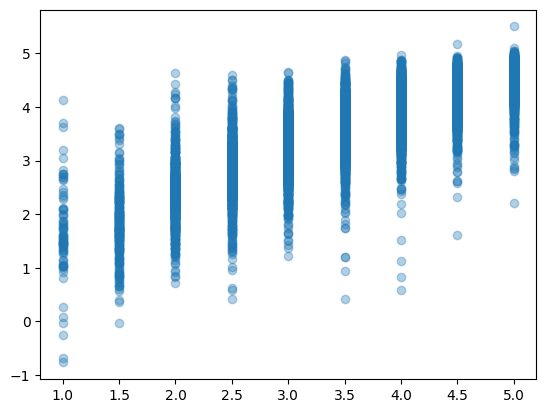

In [27]:
#Checking the model
plt.scatter(y_test, y_predict, alpha= 0.34)

### Step 10 :- Re - Checking the model 

In [28]:
print(f"R²:  {regr.score(x_test, y_test):.4f}")

R²:  0.7116


Now the score is around 71% which is satisfactory for our model

## Section 5 :- Testing the model on a real restraunt
 * We will test our new model with our own imaginary restraunt.
 * Feel free to change the given values below and see the model in action.

In [29]:
import numpy as np

# Satyam's Kitchen details
# Format: [alcohol?, good_for_kids, has_bike_parking, has_wifi, is_open,
#           price_range, take_reservations, takes_credit_cards,
#           average_review_length, average_review_sentiment,
#           number_cool_votes, number_tips, average_number_fans,
#           average_review_count, average_number_years_elite]

satyams_kitchen = np.array([[
    0,      # alcohol?                  (0 = No, 1 = Yes)
    1,      # good_for_kids             (0 = No, 1 = Yes)
    1,      # has_bike_parking          (0 = No, 1 = Yes)
    1,      # has_wifi                  (0 = No, 1 = Yes)
    1,      # is_open                   (0 = No, 1 = Yes)
    2,      # price_range               (1 = cheap, 4 = expensive)
    1,      # take_reservations         (0 = No, 1 = Yes)
    1,      # takes_credit_cards        (0 = No, 1 = Yes)
    150,    # average_review_length     (characters)
    0.8,    # average_review_sentiment  (-1 to 1)
    10,     # number_cool_votes
    5,      # number_tips
    20,     # average_number_fans
    50,     # average_review_count
    2,      # average_number_years_elite
]])

# Predict the star rating
predicted_stars = regr.predict(satyams_kitchen)
print(f"Predicted Star Rating for Satyam's Kitchen: {predicted_stars[0][0]:.2f} ⭐")

Predicted Star Rating for Satyam's Kitchen: 4.29 ⭐


c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
